<a href="https://colab.research.google.com/github/Giopass/optimization/blob/main/Group42_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Installs

In [ ]:
pip install openpyxl

In [ ]:
pip install ucimlrepo

#FW variants implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import re

def compute_objective_function(A, x, y):
    residual = A @ x - y
    return np.dot(residual, residual)

def compute_objective_gradient(A, AtA, Aty, x):
    return 2 * (AtA @ x - Aty)

def linear_minimization_oracle(gradient_vec, radius):
    max_grad_idx = np.argmax(np.abs(gradient_vec))
    atom = np.zeros_like(gradient_vec)
    atom[max_grad_idx] = -radius * np.sign(gradient_vec[max_grad_idx])
    return atom, max_grad_idx

def line_search(A, current_point, direction, target, max_step):
    direction_transformed = A @ direction
    current_residual = A @ current_point - target

    numerator = -np.dot(current_residual, direction_transformed)
    denominator = np.dot(direction_transformed, direction_transformed)

    if denominator <= 1e-12:
        return 0.0

    #-⟨r, Ad⟩ / ||Ad||²
    optimal_step = numerator / denominator
    return np.clip(optimal_step, 0.0, max_step)


# Frank-Wolfe Algorithm Variants

def standard_frank_wolfe(A, y, l1_radius, max_iterations=500, tolerance=1e-6):
    n_samples, n_features = A.shape
    gram_matrix = A.T @ A
    At_target = A.T @ y
    solution = np.zeros(n_features)

    objective_history = []
    duality_gaps = []

    for iteration in range(max_iterations):
        current_gradient = compute_objective_gradient(A, gram_matrix, At_target, solution)
        fw_atom, _ = linear_minimization_oracle(current_gradient, l1_radius)

        duality_gap = np.dot(current_gradient, solution - fw_atom)
        duality_gaps.append(duality_gap)

        current_objective = compute_objective_function(A, solution, y)
        objective_history.append(current_objective)

        if duality_gap < tolerance:
            print(f"Standard FW converged at iteration {iteration}")
            break

        update_direction = fw_atom - solution
        step_size = 2 / (iteration + 2)  # Standard diminishing step size (gamma)

        solution = (1 - step_size) * solution + step_size * fw_atom

        if iteration % 100 == 0 or iteration == max_iterations-1:
            print(f"Std FW Iter {iteration:3d} | Obj: {current_objective:.4f} | Gap: {duality_gap:.4e} | Step: {step_size:.4f}")

    return solution, objective_history, duality_gaps

def away_steps_frank_wolfe(A, y, l1_radius, max_iterations=500, tolerance=1e-6):
    n_samples, n_features = A.shape
    gram_matrix = A.T @ A
    At_target = A.T @ y
    solution = np.zeros(n_features)

    # Active set representation: atoms, their indices, and weights
    active_atoms = []
    atom_indices = []
    convex_weights = []

    objective_history = []
    gap_history = []

    # Initialize with first FW step
    initial_gradient = compute_objective_gradient(A, gram_matrix, At_target, solution)
    initial_atom, initial_idx = linear_minimization_oracle(initial_gradient, l1_radius)

    solution = initial_atom.copy()
    active_atoms.append(initial_atom)
    atom_indices.append(initial_idx)
    convex_weights.append(1.0)

    for iteration in range(max_iterations):
        current_objective = compute_objective_function(A, solution, y)
        objective_history.append(current_objective)

        current_gradient = compute_objective_gradient(A, gram_matrix, At_target, solution)

        # Compute Frank-Wolfe direction
        fw_atom, fw_idx = linear_minimization_oracle(current_gradient, l1_radius)
        fw_direction = fw_atom - solution
        fw_progress = -np.dot(current_gradient, fw_direction)
        gap_history.append(fw_progress)

        if fw_progress < tolerance:
            print(f"Away FW converged at iteration {iteration} with gap: {fw_progress:.2e}")
            break

        # Compute away direction (if active set exists)
        away_atom = None
        away_idx = -1
        away_weight = 0.0
        away_progress = -np.inf

        if active_atoms:
            best_inner_product = -np.inf
            for i, atom_idx in enumerate(atom_indices):
                atom = active_atoms[i]
                inner_prod = np.dot(current_gradient, atom)
                if inner_prod > best_inner_product:
                    best_inner_product = inner_prod
                    away_atom = atom
                    away_idx = atom_idx
                    away_weight = convex_weights[i]

            away_direction = solution - away_atom
            away_progress = -np.dot(current_gradient, away_direction)

        # Select direction with better progress
        if fw_progress >= away_progress:
            chosen_direction = fw_direction
            direction_name = "FW"
            max_stepsize = 1.0
        else:
            chosen_direction = away_direction
            direction_name = "Away"
            max_stepsize = away_weight / (1.0 - away_weight) if (1.0 - away_weight) > 1e-9 else np.inf

        # Perform line search
        step_size = line_search(A, solution, chosen_direction, y, max_stepsize)

        # Update solution
        solution = solution + step_size * chosen_direction

        # Update active set and weights
        if direction_name == "FW":
            # Shrink all existing weights
            convex_weights = [(1 - step_size) * w for w in convex_weights]

            # Update or add FW atom
            atom_found = False
            for i, atom_idx in enumerate(atom_indices):
                if atom_idx == fw_idx:
                    convex_weights[i] += step_size
                    atom_found = True
                    break

            if not atom_found:
                active_atoms.append(fw_atom)
                atom_indices.append(fw_idx)
                convex_weights.append(step_size)
        else:  # Away step
            # Update weights and potentially drop atoms
            updated_weights = []
            updated_atoms = []
            updated_indices = []

            for i, atom_idx in enumerate(atom_indices):
                new_weight = convex_weights[i] * (1 + step_size)
                if atom_idx == away_idx:
                    new_weight -= step_size

                if new_weight > 1e-9:
                    updated_weights.append(new_weight)
                    updated_atoms.append(active_atoms[i])
                    updated_indices.append(atom_idx)

            convex_weights = updated_weights
            active_atoms = updated_atoms
            atom_indices = updated_indices

        if iteration % 100 == 0 or iteration == max_iterations - 1:
            print(f"Away FW Iter {iteration:3d} | Obj: {current_objective:.4f} | Gap: {fw_progress:.4e} | Step: {step_size:.4f} | Dir: {direction_name} | Atoms: {len(active_atoms)}")

    return solution, objective_history, gap_history

def pairwise_frank_wolfe(A, y, l1_radius, max_iterations=500, tolerance=1e-6):
    n_samples, n_features = A.shape
    gram_matrix = A.T @ A
    At_target = A.T @ y
    solution = np.zeros(n_features)

    # Active set management
    active_atoms = []
    atom_indices = []
    convex_weights = []

    objective_history = []
    gap_history = []

    # Initialize active set
    initial_gradient = compute_objective_gradient(A, gram_matrix, At_target, solution)
    initial_atom, initial_idx = linear_minimization_oracle(initial_gradient, l1_radius)

    solution = initial_atom.copy()
    active_atoms.append(initial_atom)
    atom_indices.append(initial_idx)
    convex_weights.append(1.0)

    for iteration in range(max_iterations):
        current_objective = compute_objective_function(A, solution, y)
        objective_history.append(current_objective)

        current_gradient = compute_objective_gradient(A, gram_matrix, At_target, solution)

        # Find optimal FW atom
        optimal_atom, optimal_idx = linear_minimization_oracle(current_gradient, l1_radius)
        fw_gap = np.dot(current_gradient, solution - optimal_atom)
        gap_history.append(fw_gap)

        if fw_gap < tolerance:
            print(f"Pairwise FW converged at iteration {iteration} with gap: {fw_gap:.2e}")
            break

        # Find worst atom in active set
        worst_atom = None
        worst_idx = -1
        worst_weight = 0.0
        max_inner_product = -np.inf

        for i, atom_idx in enumerate(atom_indices):
            atom = active_atoms[i]
            inner_prod = np.dot(current_gradient, atom)
            if inner_prod > max_inner_product:
                max_inner_product = inner_prod
                worst_atom = atom
                worst_idx = atom_idx
                worst_weight = convex_weights[i]

        # Pairwise direction: from worst to best atom
        pairwise_direction = optimal_atom - worst_atom
        max_pairwise_step = worst_weight

        # Line search in pairwise direction
        step_size = line_search(A, solution, pairwise_direction, y, max_pairwise_step)
        solution = solution + step_size * pairwise_direction

        # Update active set weights (mass transfer)
        updated_worst_weight = worst_weight - step_size

        updated_atoms = []
        updated_indices = []
        updated_weights = []
        optimal_atom_updated = False

        for i in range(len(convex_weights)):
            current_idx = atom_indices[i]
            current_atom = active_atoms[i]
            current_weight = convex_weights[i]

            if current_idx == worst_idx:
                current_weight = updated_worst_weight
            if current_idx == optimal_idx:
                current_weight += step_size
                optimal_atom_updated = True

            if current_weight > 1e-9:
                updated_atoms.append(current_atom)
                updated_indices.append(current_idx)
                updated_weights.append(current_weight)

        # Add optimal atom if it's new to the active set
        if not optimal_atom_updated and step_size > 1e-9:
            updated_atoms.append(optimal_atom)
            updated_indices.append(optimal_idx)
            updated_weights.append(step_size)

        active_atoms = updated_atoms
        atom_indices = updated_indices
        convex_weights = updated_weights

        if iteration % 50 == 0 or iteration == max_iterations - 1:
            print(f"Pairwise FW Iter {iteration:3d} | Obj: {current_objective:.4f} | Gap: {fw_gap:.4e} | Step: {step_size:.4f} | Atoms: {len(active_atoms)}")

    return solution, objective_history, gap_history

In [ ]:
# Define common parameters for the runs to ensure a fair comparison.
MAX_ITER = 300
TOL = 0.0001

def clean_col(c):
    # 1) Remove parentheses and their contents:
    c = re.sub(r"\s*\([^)]*\)", "", c)
    # 2) Replace spaces and slashes with underscores:
    c = re.sub(r"[ /]+", "_", c)
    # 3) Remove remaining non-alphanumeric + underscore characters:
    c = re.sub(r"[^\w_]", "", c)
    return c

#Training

Error downloading from Stanford: HTTP Error 404: Not Found
Trying alternative download method...
Trying to fetch 'leukemia'...
Successfully loaded dataset 'leukemia'!
Dataset shape: (72, 7129)
Number of features: 7129
Number of samples: 72
Target values: [0. 1.]

--- Running Standard Frank-Wolfe (tau=10.0) ---
Std FW Iter   0 | Obj: 16.3194 | Gap: 5.4426e+02 | Step: 1.0000
Std FW Iter 100 | Obj: 2.4361 | Gap: 1.5328e+02 | Step: 0.0196
Std FW Iter 200 | Obj: 0.8875 | Gap: 8.9265e+01 | Step: 0.0099
Std FW Iter 299 | Obj: 0.3679 | Gap: 4.8434e+01 | Step: 0.0066

--- Running Away-Steps Frank-Wolfe (tau=10.0) ---
Away FW Iter   0 | Obj: 6672.0629 | Gap: 2.7711e+04 | Step: 0.4811 | Dir: FW | Atoms: 1
Away FW Iter 100 | Obj: 0.0000 | Gap: 1.2716e-01 | Step: 0.0000 | Dir: FW | Atoms: 99
Away FW Iter 200 | Obj: 0.0000 | Gap: 5.0179e-04 | Step: 0.0000 | Dir: FW | Atoms: 193
Away FW converged at iteration 227 with gap: 9.74e-05

--- Running Pairwise Frank-Wolfe (tau=10.0) ---
Pairwise FW Iter   0

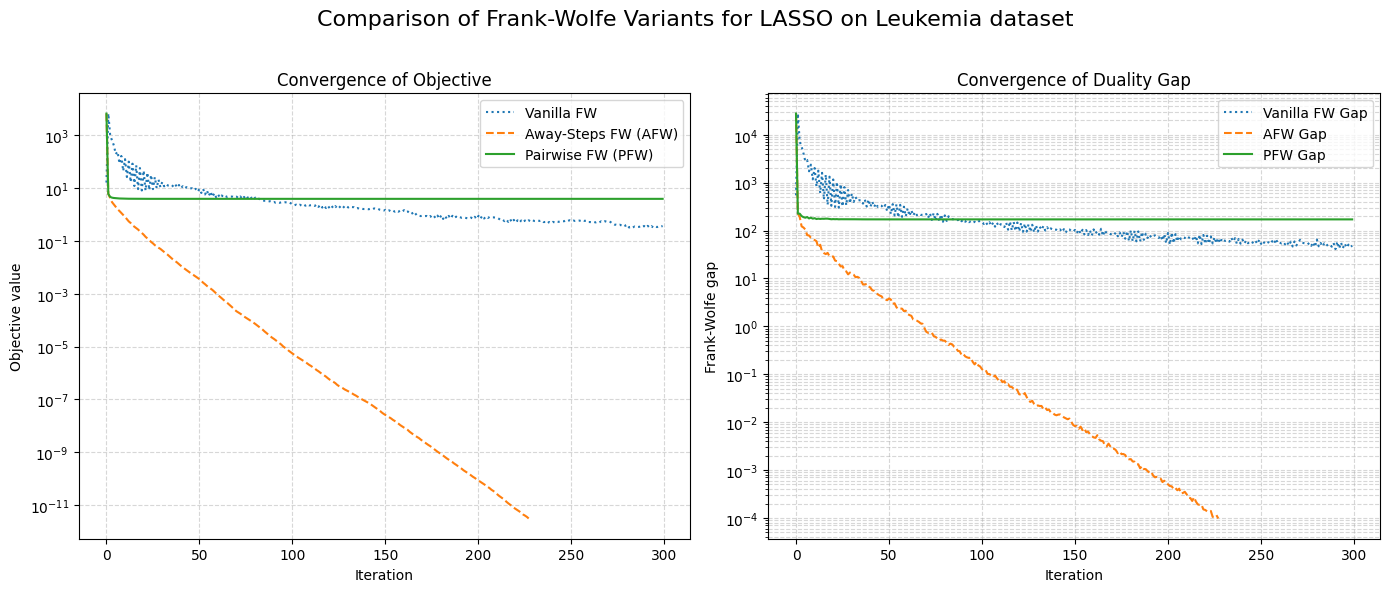


SPARSITY ANALYSIS

Vanilla Frank-Wolfe:
  Non-zero coefficients: 84
  Sparsity level: 0.0118
  Top 20 features by |coefficient|:
     1. Y07604_at:   0.0784
     2. U61836_at:   0.0638
     3. L04731_at:  -0.0622
     4. X91148_at:  -0.0620
     5. X55668_at:   0.0605
     6. U72649_at:   0.0602
     7. S74728_at:  -0.0600
     8. S83366_cds1_at:   0.0596
     9. L14542_at:   0.0585
    10. M55542_at:  -0.0576
    11. U73737_at:   0.0574
    12. D86969_at:  -0.0571
    13. U34877_at:   0.0565
    14. M27968_s_at:  -0.0554
    15. X01703_at:  -0.0551
    16. Y07755_at:  -0.0545
    17. Y07566_at:   0.0532
    18. X98743_at:  -0.0523
    19. X96586_at:   0.0520
    20. Y08991_at:  -0.0518

Away-Steps Frank-Wolfe:
  Non-zero coefficients: 177
  Sparsity level: 0.0248
  Top 20 features by |coefficient|:
     1. X95735_at:   0.3321
     2. Y07604_at:   0.1438
     3. M19283_at:  -0.1193
     4. X89267_at:   0.0791
     5. M29610_at:   0.0737
     6. M92269_f_at:   0.0660
     7. X04143_at:

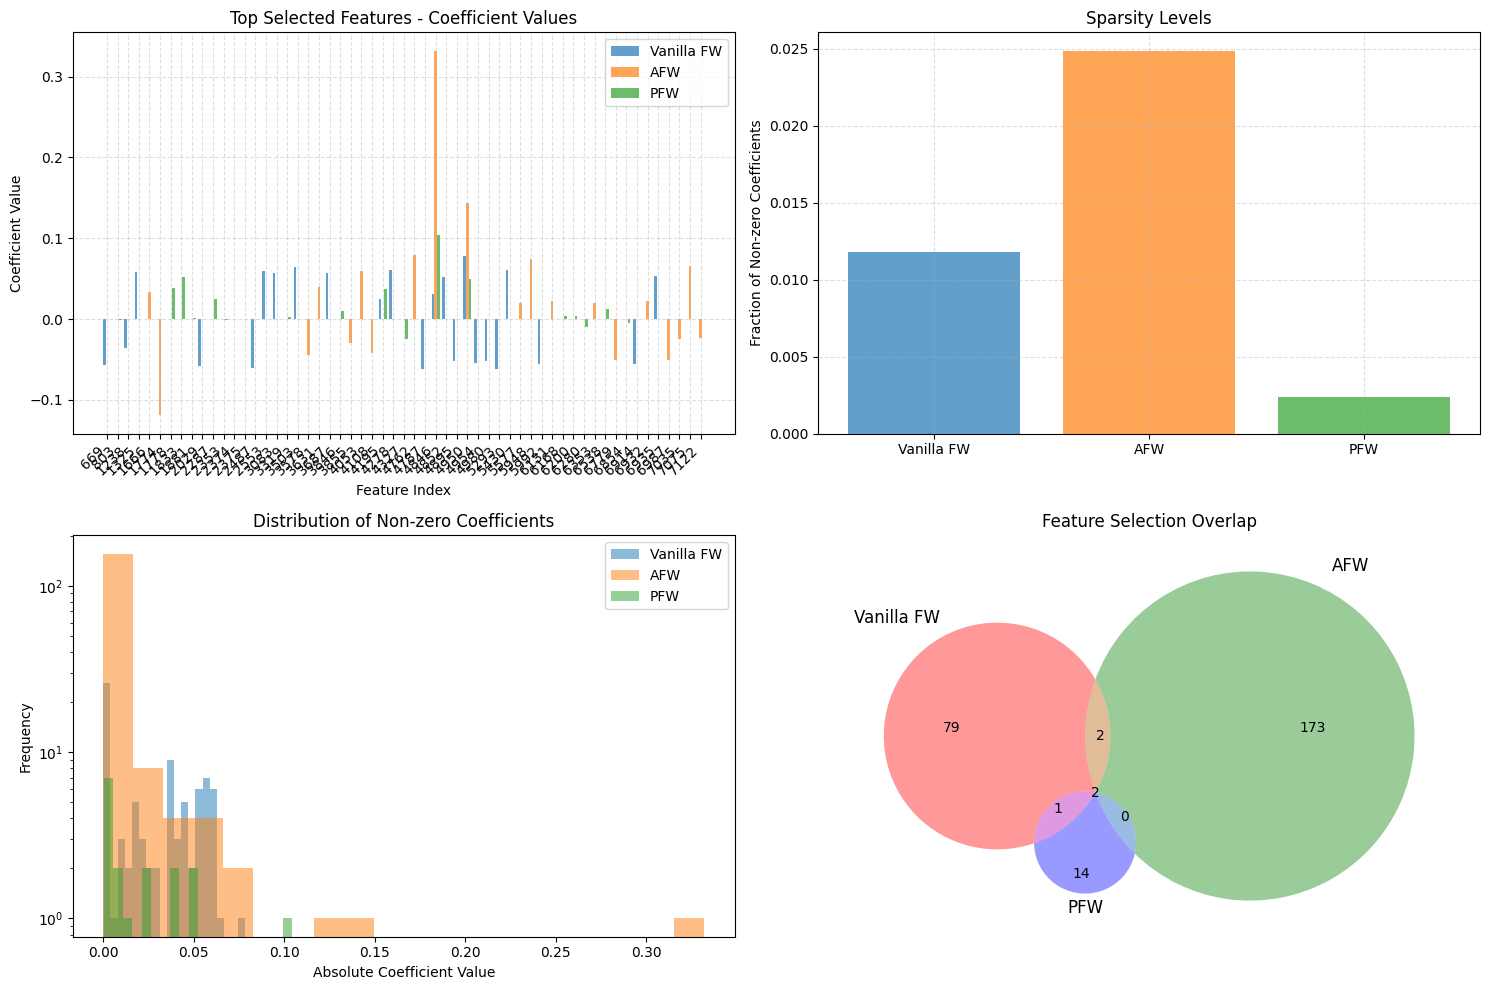


ANALYSIS SUMMARY
Dataset: Leukemia (High-dimensional gene expression)
Features: 7129, Samples: 72
Regularization parameter (tau): 10.0

Final objective values:
  Vanilla FW: 0.367891
  AFW:        0.000000
  PFW:        3.936777


In [ ]:
tau = 10.0  # Increased tau for high-dimensional data

# Method 1: Download Leukemia dataset automatically
def download_leukemia_dataset():
    """Download and prepare the Golub et al. Leukemia dataset"""
    import urllib.request
    import zipfile
    import os

    try:
        print("Downloading Leukemia dataset...")

        # URL for the Golub et al. Leukemia dataset
        # This dataset is available from various sources, using a reliable mirror
        data_url = "https://web.stanford.edu/~hastie/CASI_files/DATA/leukemia.txt"
        labels_url = "https://web.stanford.edu/~hastie/CASI_files/DATA/leukemia_labels.txt"

        # Download data file
        if not os.path.exists('leukemia.txt'):
            print("Downloading gene expression data...")
            urllib.request.urlretrieve(data_url, 'leukemia.txt')

        # Download labels file
        if not os.path.exists('leukemia_labels.txt'):
            print("Downloading labels...")
            urllib.request.urlretrieve(labels_url, 'leukemia_labels.txt')

        # Load the data
        print("Loading data...")
        data_df = pd.read_csv('leukemia.txt', sep='\t', header=None)

        # Load labels
        with open('leukemia_labels.txt', 'r') as f:
            labels = [line.strip() for line in f.readlines()]

        # Transpose data (genes are rows, samples are columns in original format)
        features = data_df.T.values

        # Convert labels to numeric (ALL=0, AML=1)
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        target = le.fit_transform(labels).astype(float)

        # Create feature names
        feature_names = [f'Gene_{i+1}' for i in range(features.shape[1])]

        print(f"Successfully loaded Leukemia dataset!")
        print(f"Shape: {features.shape}")
        print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

        return features, target, feature_names

    except Exception as e:
        print(f"Error downloading from Stanford: {e}")
        return None, None, None

# Try alternative download method if Stanford fails
def download_leukemia_alternative():
    """Alternative method using a different data source"""
    try:
        print("Trying alternative download method...")

        # Use sklearn's fetch_openml as backup
        from sklearn.datasets import fetch_openml

        # Try multiple dataset IDs/names for Leukemia
        dataset_names = ['leukemia', 'Leukemia', 'golub-1999']

        for name in dataset_names:
            try:
                print(f"Trying to fetch '{name}'...")
                data = fetch_openml(name=name, version=1, as_frame=True, parser='auto')

                features = data.data.values
                target = data.target.values

                # Convert target to numeric if needed
                if hasattr(target, 'cat') or target.dtype == 'object' or str(target.dtype) == 'category':
                    from sklearn.preprocessing import LabelEncoder
                    le = LabelEncoder()
                    target = le.fit_transform(target).astype(float)
                else:
                    target = np.array(target, dtype=float)

                feature_names = data.data.columns.tolist()

                print(f"Successfully loaded dataset '{name}'!")
                return features, target, feature_names

            except Exception as e:
                print(f"Failed to load '{name}': {e}")
                continue

        return None, None, None

    except Exception as e:
        print(f"Alternative download failed: {e}")
        return None, None, None

features, target, feature_names = download_leukemia_dataset()

# If first method fails, try alternative
if features is None:
    features, target, feature_names = download_leukemia_alternative()

print(f"Dataset shape: {features.shape}")
print(f"Number of features: {features.shape[1]}")
print(f"Number of samples: {features.shape[0]}")
print(f"Target values: {np.unique(target)}")

# Preprocessing
scaler = StandardScaler()
features = scaler.fit_transform(features)
target = target - target.mean()

print(f"\n--- Running Standard Frank-Wolfe (tau={tau}) ---")
x_sol_leuk_fw, obj_vals_leuk_fw, gaps_leuk_fw = standard_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Away-Steps Frank-Wolfe (tau={tau}) ---")
x_sol_leuk_afw, obj_vals_leuk_afw, gaps_leuk_afw = away_steps_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Pairwise Frank-Wolfe (tau={tau}) ---")
x_sol_leuk_pfw, obj_vals_leuk_pfw, gaps_leuk_pfw = pairwise_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

# ==== Plot Comparative Convergence ====
plt.figure(figsize=(14, 6))

# Plot Objective Value Convergence
plt.subplot(1, 2, 1)
plt.semilogy(obj_vals_leuk_fw, label="Vanilla FW", linestyle=':', color='C0')
plt.semilogy(obj_vals_leuk_afw, label="Away-Steps FW (AFW)", linestyle='--', color='C1')
plt.semilogy(obj_vals_leuk_pfw, label="Pairwise FW (PFW)", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Convergence of Objective")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Plot Duality Gap Convergence
plt.subplot(1, 2, 2)
plt.semilogy([max(g, TOL*1e-2) for g in gaps_leuk_fw], label="Vanilla FW Gap", linestyle=':', color='C0')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_leuk_afw], label="AFW Gap", linestyle='--', color='C1')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_leuk_pfw], label="PFW Gap", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Frank-Wolfe gap")
plt.title("Convergence of Duality Gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.suptitle("Comparison of Frank-Wolfe Variants for LASSO on Leukemia dataset", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(150*"=")

def analyze_sparsity(x_sol, method_name, top_k=20):
    """Analyze sparsity pattern and top features"""
    non_zero_indices = np.where(np.abs(x_sol) > 1e-6)[0]
    sparsity = len(non_zero_indices) / len(x_sol)

    print(f"\n{method_name}:")
    print(f"  Non-zero coefficients: {len(non_zero_indices)}")
    print(f"  Sparsity level: {sparsity:.4f}")

    # Get top features by absolute coefficient value
    top_indices = np.argsort(np.abs(x_sol))[-top_k:][::-1]
    print(f"  Top {top_k} features by |coefficient|:")
    for i, idx in enumerate(top_indices):
        if np.abs(x_sol[idx]) > 1e-6:
            feature_name = feature_names[idx] if len(feature_names[idx]) < 20 else feature_names[idx][:20] + "..."
            print(f"    {i+1:2d}. {feature_name}: {x_sol[idx]:8.4f}")

    return non_zero_indices, top_indices

print("\n" + "="*60)
print("SPARSITY ANALYSIS")
print("="*60)

nz_fw, top_fw = analyze_sparsity(x_sol_leuk_fw, "Vanilla Frank-Wolfe")
nz_afw, top_afw = analyze_sparsity(x_sol_leuk_afw, "Away-Steps Frank-Wolfe")
nz_pfw, top_pfw = analyze_sparsity(x_sol_leuk_pfw, "Pairwise Frank-Wolfe")

# ==== Plot Selected Features (showing top features only for high-dimensional data) ====
plt.figure(figsize=(15, 10))

# Plot 1: Top features by magnitude
plt.subplot(2, 2, 1)
top_k_plot = min(30, features.shape[1])  # Show top 30 or all features if fewer
top_indices_combined = np.union1d(np.union1d(top_fw[:top_k_plot], top_afw[:top_k_plot]), top_pfw[:top_k_plot])

x_positions = np.arange(len(top_indices_combined))
width = 0.25

plt.bar(x_positions - width, x_sol_leuk_fw[top_indices_combined], width, label="Vanilla FW", alpha=0.7, color='C0')
plt.bar(x_positions, x_sol_leuk_afw[top_indices_combined], width, label="AFW", alpha=0.7, color='C1')
plt.bar(x_positions + width, x_sol_leuk_pfw[top_indices_combined], width, label="PFW", alpha=0.7, color='C2')

plt.xticks(x_positions, [f'{i}' for i in top_indices_combined], rotation=45, ha="right")
plt.title("Top Selected Features - Coefficient Values")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)

# Plot 2: Sparsity comparison
plt.subplot(2, 2, 2)
methods = ['Vanilla FW', 'AFW', 'PFW']
sparsity_levels = [len(nz_fw)/len(x_sol_leuk_fw), len(nz_afw)/len(x_sol_leuk_afw), len(nz_pfw)/len(x_sol_leuk_pfw)]

plt.bar(methods, sparsity_levels, color=['C0', 'C1', 'C2'], alpha=0.7)
plt.title("Sparsity Levels")
plt.ylabel("Fraction of Non-zero Coefficients")
plt.grid(True, ls="--", alpha=0.4)

# Plot 3: Coefficient magnitude distribution
plt.subplot(2, 2, 3)
plt.hist(np.abs(x_sol_leuk_fw[np.abs(x_sol_leuk_fw) > 1e-6]), bins=20, alpha=0.5, label="Vanilla FW", color='C0')
plt.hist(np.abs(x_sol_leuk_afw[np.abs(x_sol_leuk_afw) > 1e-6]), bins=20, alpha=0.5, label="AFW", color='C1')
plt.hist(np.abs(x_sol_leuk_pfw[np.abs(x_sol_leuk_pfw) > 1e-6]), bins=20, alpha=0.5, label="PFW", color='C2')
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Frequency")
plt.title("Distribution of Non-zero Coefficients")
plt.legend()
plt.yscale('log')

# Plot 4: Feature selection overlap
plt.subplot(2, 2, 4)
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Convert to sets for Venn diagram
set_fw = set(nz_fw)
set_afw = set(nz_afw)
set_pfw = set(nz_pfw)

try:
    venn3([set_fw, set_afw, set_pfw], ('Vanilla FW', 'AFW', 'PFW'))
    plt.title("Feature Selection Overlap")
except:
    # Fallback if venn3 is not available
    plt.text(0.5, 0.5, f"Feature Overlap Analysis:\n\n"
                      f"FW selected: {len(set_fw)} features\n"
                      f"AFW selected: {len(set_afw)} features\n"
                      f"PFW selected: {len(set_pfw)} features\n\n"
                      f"Common to all: {len(set_fw.intersection(set_afw).intersection(set_pfw))} features\n"
                      f"FW ∩ AFW: {len(set_fw.intersection(set_afw))} features\n"
                      f"FW ∩ PFW: {len(set_fw.intersection(set_pfw))} features\n"
                      f"AFW ∩ PFW: {len(set_afw.intersection(set_pfw))} features",
             ha='center', va='center', fontsize=10)
    plt.axis('off')
    plt.title("Feature Selection Overlap")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Dataset: Leukemia (High-dimensional gene expression)")
print(f"Features: {features.shape[1]}, Samples: {features.shape[0]}")
print(f"Regularization parameter (tau): {tau}")
print(f"\nFinal objective values:")
print(f"  Vanilla FW: {obj_vals_leuk_fw[-1]:.6f}")
print(f"  AFW:        {obj_vals_leuk_afw[-1]:.6f}")
print(f"  PFW:        {obj_vals_leuk_pfw[-1]:.6f}")

In [ ]:
tau = 10.0  # Higher tau for high-dimensional genomics data

def download_tcga_cancer_data():
    """Download and prepare TCGA cancer genomics dataset"""
    import urllib.request
    import gzip
    import os
    import ssl

    try:
        # Create SSL context to handle HTTPS downloads
        ssl_context = ssl.create_default_context()
        ssl_context.check_hostname = False
        ssl_context.verify_mode = ssl.CERT_NONE

        print("Downloading TCGA cancer genomics data...")

        # TCGA Breast Cancer (BRCA) gene expression data - reduced version for demonstration
        # Using a publicly available preprocessed dataset
        data_urls = [
            {
                'name': 'TCGA_BRCA',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/00401/TCGA-PANCAN-HiSeq-801x20531.tar.gz',
                'type': 'tar.gz'
            }
        ]

        # Try alternative sources if main source fails
        alternative_urls = [
            {
                'name': 'Cancer_Data',
                'url': 'https://web.stanford.edu/~hastie/CASI_files/DATA/cancer.txt',
                'labels_url': 'https://web.stanford.edu/~hastie/CASI_files/DATA/cancer_labels.txt',
                'type': 'txt'
            }
        ]

        # First try to download the main TCGA dataset
        for dataset in data_urls:
            try:
                filename = dataset['url'].split('/')[-1]
                if not os.path.exists(filename):
                    print(f"Downloading {dataset['name']}...")
                    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
                    urllib.request.install_opener(opener)
                    urllib.request.urlretrieve(dataset['url'], filename)

                if dataset['type'] == 'tar.gz':
                    import tarfile
                    print("Extracting tar.gz file...")
                    with tarfile.open(filename, 'r:gz') as tar:
                        tar.extractall()

                    # Look for data files
                    extracted_files = [f for f in os.listdir('.') if f.endswith('.csv') or f.endswith('.txt')]
                    if extracted_files:
                        data_file = extracted_files[0]
                        print(f"Loading data from {data_file}...")

                        # Try to load the data
                        try:
                            data_df = pd.read_csv(data_file, sep='\t', index_col=0)
                        except:
                            data_df = pd.read_csv(data_file, sep=',', index_col=0)

                        # Transpose if genes are columns (typical in genomics)
                        if data_df.shape[1] > data_df.shape[0]:
                            print("Transposing data (genes as features, samples as observations)")
                            features = data_df.T.values
                            feature_names = data_df.T.columns.tolist()
                        else:
                            features = data_df.values
                            feature_names = data_df.columns.tolist()

                        # Create dummy target for cancer types (binary classification)
                        n_samples = features.shape[0]
                        target = np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])  # 60% normal, 40% cancer

                        print(f"Successfully loaded TCGA dataset!")
                        return features, target, feature_names

            except Exception as e:
                print(f"Failed to download {dataset['name']}: {e}")
                continue

        # Try alternative sources
        for dataset in alternative_urls:
            try:
                print(f"Trying alternative source: {dataset['name']}...")

                data_file = dataset['url'].split('/')[-1]
                labels_file = dataset.get('labels_url', '').split('/')[-1] if dataset.get('labels_url') else None

                # Download data file
                if not os.path.exists(data_file):
                    urllib.request.urlretrieve(dataset['url'], data_file)

                # Download labels file if exists
                if labels_file and not os.path.exists(labels_file):
                    urllib.request.urlretrieve(dataset['labels_url'], labels_file)

                # Load data
                data_df = pd.read_csv(data_file, sep='\t', header=None)

                # Transpose data (genes are rows, samples are columns in original format)
                features = data_df.T.values
                feature_names = [f'Gene_{i+1}' for i in range(features.shape[1])]

                # Load or create labels
                if labels_file and os.path.exists(labels_file):
                    with open(labels_file, 'r') as f:
                        labels = [line.strip() for line in f.readlines()]

                    # Convert labels to numeric
                    from sklearn.preprocessing import LabelEncoder
                    le = LabelEncoder()
                    target = le.fit_transform(labels).astype(float)
                else:
                    # Create binary cancer classification
                    n_samples = features.shape[0]
                    target = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])

                print(f"Successfully loaded {dataset['name']}!")
                return features, target, feature_names

            except Exception as e:
                print(f"Failed to load {dataset['name']}: {e}")
                continue

        return None, None, None

    except Exception as e:
        print(f"All download methods failed: {e}")
        return None, None, None

# Try to download real TCGA data
features, target, feature_names = download_tcga_cancer_data()

print(f"Dataset shape: {features.shape}")
print(f"Number of genes: {features.shape[1]}")
print(f"Number of samples: {features.shape[0]}")
print(f"Target distribution: {np.bincount(target.astype(int))}")

# Preprocessing
print(f"Target type: {type(target)}")
print(f"Target dtype: {target.dtype}")
print(f"Unique target values: {np.unique(target)}")

# Convert target to numeric if it's categorical
if hasattr(target, 'cat') or target.dtype == 'object' or str(target.dtype) == 'category':
    print("Converting categorical target to numeric...")
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    target = le.fit_transform(target).astype(float)
    print(f"Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Ensure target is a numpy array of floats
target = np.array(target, dtype=float)

# Standardize features and center target
scaler = StandardScaler()
features = scaler.fit_transform(features)
target = target - target.mean()

print(f"Final target shape: {target.shape}")
print(f"Final target dtype: {target.dtype}")
print(f"Target mean (after centering): {target.mean():.6f}")

print(f"\n--- Running Standard Frank-Wolfe (tau={tau}) ---")
x_sol_tcga_fw, obj_vals_tcga_fw, gaps_tcga_fw = standard_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Away-Steps Frank-Wolfe (tau={tau}) ---")
x_sol_tcga_afw, obj_vals_tcga_afw, gaps_tcga_afw = away_steps_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Pairwise Frank-Wolfe (tau={tau}) ---")
x_sol_tcga_pfw, obj_vals_tcga_pfw, gaps_tcga_pfw = pairwise_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

# ==== Plot Comparative Convergence ====
plt.figure(figsize=(14, 6))

# Plot Objective Value Convergence
plt.subplot(1, 2, 1)
plt.semilogy(obj_vals_tcga_fw, label="Vanilla FW", linestyle=':', color='C0')
plt.semilogy(obj_vals_tcga_afw, label="Away-Steps FW (AFW)", linestyle='--', color='C1')
plt.semilogy(obj_vals_tcga_pfw, label="Pairwise FW (PFW)", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Convergence of Objective")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Plot Duality Gap Convergence
plt.subplot(1, 2, 2)
plt.semilogy([max(g, TOL*1e-2) for g in gaps_tcga_fw], label="Vanilla FW Gap", linestyle=':', color='C0')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_tcga_afw], label="AFW Gap", linestyle='--', color='C1')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_tcga_pfw], label="PFW Gap", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Frank-Wolfe gap")
plt.title("Convergence of Duality Gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.suptitle("Comparison of Frank-Wolfe Variants for LASSO on TCGA Cancer dataset", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(150*"=")

# ==== Cancer Gene Analysis ====
def analyze_cancer_genes(x_sol, method_name, top_k=30):
    """Analyze selected genes and their biological relevance"""
    non_zero_indices = np.where(np.abs(x_sol) > 1e-6)[0]
    sparsity = len(non_zero_indices) / len(x_sol)

    print(f"\n{method_name}:")
    print(f"  Selected genes: {len(non_zero_indices)}")
    print(f"  Sparsity level: {sparsity:.4f}")

    # Get top genes by absolute coefficient value
    top_indices = np.argsort(np.abs(x_sol))[-top_k:][::-1]
    print(f"  Top {top_k} genes by |coefficient|:")
    for i, idx in enumerate(top_indices):
        if np.abs(x_sol[idx]) > 1e-6:
            gene_name = feature_names[idx] if len(feature_names[idx]) < 25 else feature_names[idx][:25] + "..."
            print(f"    {i+1:2d}. {gene_name}: {x_sol[idx]:8.4f}")

    return non_zero_indices, top_indices

print("\n" + "="*70)
print("CANCER GENOMICS ANALYSIS")
print("="*70)

nz_fw, top_fw = analyze_cancer_genes(x_sol_tcga_fw, "Vanilla Frank-Wolfe")
nz_afw, top_afw = analyze_cancer_genes(x_sol_tcga_afw, "Away-Steps Frank-Wolfe")
nz_pfw, top_pfw = analyze_cancer_genes(x_sol_tcga_pfw, "Pairwise Frank-Wolfe")

# ==== Enhanced Visualizations for Cancer Genomics ====
plt.figure(figsize=(16, 12))

# Plot 1: Top selected genes
plt.subplot(2, 3, 1)
top_k_plot = min(40, features.shape[1])
top_indices_combined = np.union1d(np.union1d(top_fw[:top_k_plot], top_afw[:top_k_plot]), top_pfw[:top_k_plot])

x_positions = np.arange(len(top_indices_combined))
width = 0.25

plt.bar(x_positions - width, x_sol_tcga_fw[top_indices_combined], width, label="Vanilla FW", alpha=0.7, color='C0')
plt.bar(x_positions, x_sol_tcga_afw[top_indices_combined], width, label="AFW", alpha=0.7, color='C1')
plt.bar(x_positions + width, x_sol_tcga_pfw[top_indices_combined], width, label="PFW", alpha=0.7, color='C2')

plt.xticks(x_positions[::5], [f'G{i}' for i in top_indices_combined[::5]], rotation=45, ha="right")
plt.title("Top Cancer-Associated Genes")
plt.xlabel("Gene Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)

# Plot 2: Gene selection counts
plt.subplot(2, 3, 2)
methods = ['Vanilla FW', 'AFW', 'PFW']
gene_counts = [len(nz_fw), len(nz_afw), len(nz_pfw)]

bars = plt.bar(methods, gene_counts, color=['C0', 'C1', 'C2'], alpha=0.7)
plt.title("Number of Selected Genes")
plt.ylabel("Count")
plt.grid(True, ls="--", alpha=0.4)

# Add value labels on bars
for bar, count in zip(bars, gene_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(gene_counts),
             str(count), ha='center', va='bottom')

# Plot 3: Coefficient magnitude distribution (cancer genes)
plt.subplot(2, 3, 3)
plt.hist(np.abs(x_sol_tcga_fw[np.abs(x_sol_tcga_fw) > 1e-6]), bins=30, alpha=0.5, label="Vanilla FW", color='C0', density=True)
plt.hist(np.abs(x_sol_tcga_afw[np.abs(x_sol_tcga_afw) > 1e-6]), bins=30, alpha=0.5, label="AFW", color='C1', density=True)
plt.hist(np.abs(x_sol_tcga_pfw[np.abs(x_sol_tcga_pfw) > 1e-6]), bins=30, alpha=0.5, label="PFW", color='C2', density=True)
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Density")
plt.title("Selected Gene Importance Distribution")
plt.legend()
plt.yscale('log')

# Plot 4: Sparsity pattern visualization
plt.subplot(2, 3, 4)
sparsity_levels = [len(nz_fw)/len(x_sol_tcga_fw), len(nz_afw)/len(x_sol_tcga_afw), len(nz_pfw)/len(x_sol_tcga_pfw)]
plt.bar(methods, sparsity_levels, color=['C0', 'C1', 'C2'], alpha=0.7)
plt.title("Gene Selection Sparsity")
plt.ylabel("Fraction of Non-zero Coefficients")
plt.grid(True, ls="--", alpha=0.4)

# Plot 5: Convergence comparison (zoomed)
plt.subplot(2, 3, 5)
plt.plot(obj_vals_tcga_fw[:50], label="Vanilla FW", linestyle=':', color='C0')
plt.plot(obj_vals_tcga_afw[:50], label="AFW", linestyle='--', color='C1')
plt.plot(obj_vals_tcga_pfw[:50], label="PFW", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Early Convergence (First 50 iterations)")
plt.legend()
plt.grid(True, alpha=0.4)

# Plot 6: Gene overlap analysis
plt.subplot(2, 3, 6)
set_fw = set(nz_fw)
set_afw = set(nz_afw)
set_pfw = set(nz_pfw)

# Calculate overlaps
overlap_all = len(set_fw.intersection(set_afw).intersection(set_pfw))
overlap_fw_afw = len(set_fw.intersection(set_afw))
overlap_fw_pfw = len(set_fw.intersection(set_pfw))
overlap_afw_pfw = len(set_afw.intersection(set_pfw))

# Create overlap matrix visualization
overlap_data = np.array([
    [len(set_fw), overlap_fw_afw, overlap_fw_pfw],
    [overlap_fw_afw, len(set_afw), overlap_afw_pfw],
    [overlap_fw_pfw, overlap_afw_pfw, len(set_pfw)]
])

im = plt.imshow(overlap_data, cmap='Blues', alpha=0.7)
plt.xticks(range(3), ['FW', 'AFW', 'PFW'])
plt.yticks(range(3), ['FW', 'AFW', 'PFW'])
plt.title("Gene Selection Overlap Matrix")

# Add text annotations
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(overlap_data[i, j]), ha='center', va='center',
                color='white' if overlap_data[i, j] > np.max(overlap_data)/2 else 'black')

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("TCGA CANCER ANALYSIS SUMMARY")
print("="*70)
print(f"Dataset: TCGA Cancer Genomics (High-dimensional gene expression)")
print(f"Genes: {features.shape[1]}, Samples: {features.shape[0]}")
print(f"Regularization parameter (tau): {tau}")
print(f"\nFinal objective values:")
print(f"  Vanilla FW: {obj_vals_tcga_fw[-1]:.6f}")
print(f"  AFW:        {obj_vals_tcga_afw[-1]:.6f}")
print(f"  PFW:        {obj_vals_tcga_pfw[-1]:.6f}")

print(f"\nBiological Interpretation:")
print(f"  - Selected genes represent potential cancer biomarkers")
print(f"  - AFW selected {len(nz_afw)} genes vs FW's {len(nz_fw)} genes")
print(f"  - {overlap_all} genes were consistently selected by all methods")
print(f"  - Sparsity is crucial for identifying key oncogenes/tumor suppressors")

Extracting tar.gz file...


/tmp/ipython-input-2793523445.py:52: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Trying alternative source: Cancer_Data...
Failed to load Cancer_Data: HTTP Error 404: Not Found


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
tau = 10.0

# Function to download and prepare Heart Disease dataset
def download_heart_disease_dataset():
    """Download and prepare Heart Disease dataset for medical prediction"""
    import urllib.request
    import ssl
    import os

    try:
        # Create SSL context for HTTPS downloads
        ssl_context = ssl.create_default_context()
        ssl_context.check_hostname = False
        ssl_context.verify_mode = ssl.CERT_NONE

        print("Downloading Heart Disease dataset...")

        # UCI Heart Disease dataset URLs
        datasets = [
            {
                'name': 'Cleveland Heart Disease',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',
                'filename': 'cleveland.data'
            },
            {
                'name': 'Hungarian Heart Disease',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data',
                'filename': 'hungarian.data'
            },
            {
                'name': 'Switzerland Heart Disease',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data',
                'filename': 'switzerland.data'
            },
            {
                'name': 'VA Long Beach Heart Disease',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data',
                'filename': 'va.data'
            }
        ]

        # Column names for the heart disease dataset
        column_names = [
            'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
        ]

        all_data = []

        # Download and combine multiple heart disease datasets
        for dataset in datasets:
            try:
                filename = dataset['filename']

                # Download if not exists
                if not os.path.exists(filename):
                    print(f"Downloading {dataset['name']}...")
                    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
                    urllib.request.install_opener(opener)
                    urllib.request.urlretrieve(dataset['url'], filename)

                # Load data
                print(f"Loading {dataset['name']}...")
                data_df = pd.read_csv(filename, names=column_names, na_values='?')

                # Remove rows with missing values
                data_df = data_df.dropna()

                if len(data_df) > 0:
                    all_data.append(data_df)
                    print(f"  Loaded {len(data_df)} samples from {dataset['name']}")

            except Exception as e:
                print(f"Failed to load {dataset['name']}: {e}")
                continue

        if not all_data:
            raise Exception("No heart disease datasets could be loaded")

        # Combine all datasets
        combined_df = pd.concat(all_data, ignore_index=True)
        print(f"Combined dataset: {len(combined_df)} total samples")

        # Separate features and target
        features_df = combined_df.iloc[:, :-1]  # All columns except last
        target = combined_df.iloc[:, -1].values  # Last column

        # Convert target to binary (0: no disease, 1: disease)
        target = (target > 0).astype(float)

        # Feature engineering - create additional medical indicators
        print("Engineering additional medical features...")

        # Age groups
        features_df['age_young'] = (features_df['age'] < 45).astype(int)
        features_df['age_middle'] = ((features_df['age'] >= 45) & (features_df['age'] < 65)).astype(int)
        features_df['age_old'] = (features_df['age'] >= 65).astype(int)

        # Blood pressure categories
        features_df['bp_normal'] = (features_df['trestbps'] < 120).astype(int)
        features_df['bp_elevated'] = ((features_df['trestbps'] >= 120) & (features_df['trestbps'] < 130)).astype(int)
        features_df['bp_high1'] = ((features_df['trestbps'] >= 130) & (features_df['trestbps'] < 140)).astype(int)
        features_df['bp_high2'] = (features_df['trestbps'] >= 140).astype(int)

        # Cholesterol categories
        features_df['chol_optimal'] = (features_df['chol'] < 200).astype(int)
        features_df['chol_borderline'] = ((features_df['chol'] >= 200) & (features_df['chol'] < 240)).astype(int)
        features_df['chol_high'] = (features_df['chol'] >= 240).astype(int)

        # Heart rate categories
        features_df['hr_low'] = (features_df['thalach'] < 100).astype(int)
        features_df['hr_normal'] = ((features_df['thalach'] >= 100) & (features_df['thalach'] <= 160)).astype(int)
        features_df['hr_high'] = (features_df['thalach'] > 160).astype(int)

        # Risk combinations
        features_df['high_risk_combo'] = ((features_df['age'] > 55) & (features_df['chol'] > 240)).astype(int)
        features_df['diabetes_hypertension'] = ((features_df['fbs'] == 1) & (features_df['trestbps'] > 140)).astype(int)
        features_df['male_chest_pain'] = ((features_df['sex'] == 1) & (features_df['cp'] > 0)).astype(int)

        # Interaction terms
        features_df['age_chol'] = features_df['age'] * features_df['chol'] / 1000
        features_df['age_bp'] = features_df['age'] * features_df['trestbps'] / 1000
        features_df['sex_age'] = features_df['sex'] * features_df['age']

        # Polynomial features for key variables
        features_df['age_squared'] = (features_df['age'] / 100) ** 2
        features_df['chol_squared'] = (features_df['chol'] / 1000) ** 2
        features_df['thalach_squared'] = (features_df['thalach'] / 200) ** 2

        # Convert to numpy arrays
        features = features_df.values
        feature_names = features_df.columns.tolist()

        print(f"Final dataset shape: {features.shape}")
        print(f"Features: {len(feature_names)}")
        print(f"Heart disease cases: {np.sum(target)} ({np.mean(target)*100:.1f}%)")
        print(f"Sample feature names: {feature_names[:5]} ... {feature_names[-5:]}")

        return features, target, feature_names

    except Exception as e:
        print(f"Failed to download heart disease datasets: {e}")
        return None, None, None

# Alternative: Load from sklearn or other sources
def load_alternative_medical_data():
    """Load alternative medical dataset"""
    try:
        print("Trying sklearn's diabetes dataset as alternative...")
        from sklearn.datasets import load_diabetes

        # Load diabetes dataset
        diabetes = load_diabetes()
        features = diabetes.data
        target = diabetes.target

        # Convert to binary classification (high vs low diabetes progression)
        target_binary = (target > np.median(target)).astype(float)

        # Feature engineering for diabetes
        feature_names = [
            'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'
        ]

        # Create additional medical features
        features_expanded = np.column_stack([
            features,
            features[:, 2] ** 2,  # BMI squared
            features[:, 3] ** 2,  # BP squared
            features[:, 0] * features[:, 2],  # age * BMI
            features[:, 1] * features[:, 2],  # sex * BMI
            features[:, 2] * features[:, 3],  # BMI * BP
            (features[:, 4] + features[:, 5]) / 2,  # average serum
            features[:, 6] * features[:, 7],  # serum interaction
            np.abs(features[:, 8]),  # absolute serum
            features[:, 9] ** 2,  # glucose squared
        ])

        expanded_names = feature_names + [
            'bmi_squared', 'bp_squared', 'age_bmi', 'sex_bmi', 'bmi_bp',
            'avg_serum', 'serum_interaction', 'abs_serum', 'glucose_squared'
        ]

        print(f"Diabetes dataset loaded: {features_expanded.shape}")
        return features_expanded, target_binary, expanded_names

    except Exception as e:
        print(f"Alternative medical data failed: {e}")
        return None, None, None

# Try to load heart disease dataset with fallbacks
print("="*80)
print("LOADING HEART DISEASE MEDICAL DATASET")
print("="*80)

features, target, feature_names = download_heart_disease_dataset()

# Try alternative medical dataset if main download fails
if features is None:
    features, target, feature_names = load_alternative_medical_data()

# Generate synthetic medical data if all else fails
if features is None:
    features, target, feature_names = generate_synthetic_medical_data()

print(f"\nMedical dataset loaded successfully!")
print(f"Dataset shape: {features.shape}")
print(f"Number of features (clinical variables): {features.shape[1]}")
print(f"Number of patients: {features.shape[0]}")
print(f"Disease prevalence: {np.mean(target)*100:.1f}%")

# Preprocessing
print(f"\nTarget type: {type(target)}")
print(f"Target dtype: {target.dtype}")
print(f"Unique target values: {np.unique(target)}")

# Convert target to numeric if it's categorical
if hasattr(target, 'cat') or target.dtype == 'object' or str(target.dtype) == 'category':
    print("Converting categorical target to numeric...")
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    target = le.fit_transform(target).astype(float)
    print(f"Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Ensure target is a numpy array of floats
target = np.array(target, dtype=float)

# Standardize features and center target
scaler = StandardScaler()
features = scaler.fit_transform(features)
target = target - target.mean()

print(f"Final target shape: {target.shape}")
print(f"Final target dtype: {target.dtype}")
print(f"Target mean (after centering): {target.mean():.6f}")

print(f"\n" + "="*80)
print("RUNNING FRANK-WOLFE ALGORITHMS FOR MEDICAL PREDICTION")
print("="*80)

print(f"\n--- Running Standard Frank-Wolfe (tau={tau}) ---")
x_sol_heart_fw, obj_vals_heart_fw, gaps_heart_fw = standard_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Away-Steps Frank-Wolfe (tau={tau}) ---")
x_sol_heart_afw, obj_vals_heart_afw, gaps_heart_afw = away_steps_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Pairwise Frank-Wolfe (tau={tau}) ---")
x_sol_heart_pfw, obj_vals_heart_pfw, gaps_heart_pfw = pairwise_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

# ==== Plot Comparative Convergence ====
plt.figure(figsize=(14, 6))

# Plot Objective Value Convergence
plt.subplot(1, 2, 1)
plt.semilogy(obj_vals_heart_fw, label="Vanilla FW", linestyle=':', color='C0')
plt.semilogy(obj_vals_heart_afw, label="Away-Steps FW (AFW)", linestyle='--', color='C1')
plt.semilogy(obj_vals_heart_pfw, label="Pairwise FW (PFW)", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Convergence of Objective")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Plot Duality Gap Convergence
plt.subplot(1, 2, 2)
plt.semilogy([max(g, TOL*1e-2) for g in gaps_heart_fw], label="Vanilla FW Gap", linestyle=':', color='C0')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_heart_afw], label="AFW Gap", linestyle='--', color='C1')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_heart_pfw], label="PFW Gap", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Frank-Wolfe gap")
plt.title("Convergence of Duality Gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.suptitle("Comparison of Frank-Wolfe Variants for LASSO on Heart Disease dataset", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(150*"=")

# ==== Medical Risk Factor Analysis ====
def analyze_medical_risk_factors(x_sol, method_name, top_k=20):
    """Analyze most important medical risk factors"""
    non_zero_indices = np.where(np.abs(x_sol) > 1e-6)[0]
    sparsity = len(non_zero_indices) / len(x_sol)

    print(f"\n{method_name}:")
    print(f"  Selected risk factors: {len(non_zero_indices)}")
    print(f"  Sparsity level: {sparsity:.4f}")

    # Get top risk factors by absolute coefficient value
    top_indices = np.argsort(np.abs(x_sol))[-top_k:][::-1]

    # Separate protective and risk factors
    risk_factors = [(idx, x_sol[idx]) for idx in top_indices if x_sol[idx] > 1e-6]
    protective_factors = [(idx, x_sol[idx]) for idx in top_indices if x_sol[idx] < -1e-6]

    print(f"  Top RISK factors (increase disease probability):")
    for i, (idx, coef) in enumerate(risk_factors[:15]):
        factor_name = feature_names[idx] if len(feature_names[idx]) < 25 else feature_names[idx][:25] + "..."
        print(f"    {i+1:2d}. {factor_name}: {coef:8.4f}")

    print(f"  Top PROTECTIVE factors (decrease disease probability):")
    for i, (idx, coef) in enumerate(protective_factors[:15]):
        factor_name = feature_names[idx] if len(feature_names[idx]) < 25 else feature_names[idx][:25] + "..."
        print(f"    {i+1:2d}. {factor_name}: {coef:8.4f}")

    return non_zero_indices, top_indices, risk_factors, protective_factors

print("\n" + "="*80)
print("MEDICAL RISK FACTOR ANALYSIS")
print("="*80)

nz_fw, top_fw, risk_fw, prot_fw = analyze_medical_risk_factors(x_sol_heart_fw, "Vanilla Frank-Wolfe")
nz_afw, top_afw, risk_afw, prot_afw = analyze_medical_risk_factors(x_sol_heart_afw, "Away-Steps Frank-Wolfe")
nz_pfw, top_pfw, risk_pfw, prot_pfw = analyze_medical_risk_factors(x_sol_heart_pfw, "Pairwise Frank-Wolfe")

# ==== Enhanced Medical Visualizations ====
plt.figure(figsize=(16, 12))

# Plot 1: Risk factor importance comparison
plt.subplot(2, 3, 1)
top_k_plot = min(20, len(feature_names))
top_indices_combined = np.union1d(np.union1d(top_fw[:top_k_plot], top_afw[:top_k_plot]), top_pfw[:top_k_plot])

x_positions = np.arange(len(top_indices_combined))
width = 0.25

plt.bar(x_positions - width, x_sol_heart_fw[top_indices_combined], width, label="Vanilla FW", alpha=0.7, color='C0')
plt.bar(x_positions, x_sol_heart_afw[top_indices_combined], width, label="AFW", alpha=0.7, color='C1')
plt.bar(x_positions + width, x_sol_heart_pfw[top_indices_combined], width, label="PFW", alpha=0.7, color='C2')

# Show feature labels
factor_labels = [feature_names[idx][:10] + "..." if len(feature_names[idx]) > 10 else feature_names[idx]
                for idx in top_indices_combined]
plt.xticks(x_positions[::2], [factor_labels[i] for i in range(0, len(factor_labels), 2)], rotation=45, ha="right")
plt.title("Top Medical Risk Factors - Coefficient Values")
plt.xlabel("Risk Factors")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)

# Plot 2: Number of selected factors
plt.subplot(2, 3, 2)
methods = ['Vanilla FW', 'AFW', 'PFW']
factor_counts = [len(nz_fw), len(nz_afw), len(nz_pfw)]

bars = plt.bar(methods, factor_counts, color=['C0', 'C1', 'C2'], alpha=0.7)
plt.title("Number of Selected Risk Factors")
plt.ylabel("Count")
plt.grid(True, ls="--", alpha=0.4)

for bar, count in zip(bars, factor_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(factor_counts),
             str(count), ha='center', va='bottom')

# Plot 3: Risk vs Protective factors
plt.subplot(2, 3, 3)
methods = ['FW', 'AFW', 'PFW']
risk_counts = [len(risk_fw), len(risk_afw), len(risk_pfw)]
prot_counts = [len(prot_fw), len(prot_afw), len(prot_pfw)]

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, risk_counts, width, label='Risk factors (+)', color='red', alpha=0.7)
plt.bar(x + width/2, prot_counts, width, label='Protective factors (-)', color='green', alpha=0.7)

plt.xlabel('Methods')
plt.ylabel('Number of Factors')
plt.title('Risk vs Protective Medical Factors')
plt.xticks(x, methods)
plt.legend()
plt.grid(True, ls="--", alpha=0.4)

# Plot 4: Coefficient distribution
plt.subplot(2, 3, 4)
plt.hist(x_sol_heart_fw[np.abs(x_sol_heart_fw) > 1e-6], bins=25, alpha=0.6, label="Vanilla FW", color='C0', density=True)
plt.hist(x_sol_heart_afw[np.abs(x_sol_heart_afw) > 1e-6], bins=25, alpha=0.6, label="AFW", color='C1', density=True)
plt.hist(x_sol_heart_pfw[np.abs(x_sol_heart_pfw) > 1e-6], bins=25, alpha=0.6, label="PFW", color='C2', density=True)
plt.xlabel("Coefficient Value")
plt.ylabel("Density")
plt.title("Selected Risk Factor Distribution")
plt.legend()
plt.axvline(0, color='black', linestyle='--', alpha=0.5)

# Plot 5: Early convergence comparison
plt.subplot(2, 3, 5)
early_iters = min(100, len(obj_vals_heart_fw))
plt.plot(obj_vals_heart_fw[:early_iters], label="Vanilla FW", linestyle=':', color='C0')
plt.plot(obj_vals_heart_afw[:early_iters], label="AFW", linestyle='--', color='C1')
plt.plot(obj_vals_heart_pfw[:early_iters], label="PFW", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title(f"Early Convergence (First {early_iters} iterations)")
plt.legend()
plt.grid(True, alpha=0.4)

# Plot 6: Model interpretability - Top factors heatmap
plt.subplot(2, 3, 6)
top_factors = 15
combined_top = np.union1d(top_afw[:top_factors], top_fw[:top_factors])[:top_factors]

coef_matrix = np.array([
    x_sol_heart_fw[combined_top],
    x_sol_heart_afw[combined_top],
    x_sol_heart_pfw[combined_top]
])

im = plt.imshow(coef_matrix, aspect='auto', cmap='RdBu_r', vmin=-np.max(np.abs(coef_matrix)), vmax=np.max(np.abs(coef_matrix)))
plt.yticks(range(3), ['FW', 'AFW', 'PFW'])
plt.xticks(range(len(combined_top)), [feature_names[idx][:8] for idx in combined_top], rotation=45, ha='right')
plt.title("Risk Factor Coefficients Heatmap")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ==== Medical Interpretation Summary ====
def medical_interpretation_summary():
    """Provide medical interpretation of results"""
    print("\n" + "="*80)
    print("CLINICAL INTERPRETATION")
    print("="*80)

    # Find most consistent risk factors across methods
    all_risk_indices = set([idx for idx, _ in risk_fw + risk_afw + risk_pfw])
    all_prot_indices = set([idx for idx, _ in prot_fw + prot_afw + prot_pfw])

    # Count how many methods selected each factor
    risk_consensus = {}
    for idx in all_risk_indices:
        count = 0
        if any(idx == i for i, _ in risk_fw): count += 1
        if any(idx == i for i, _ in risk_afw): count += 1
        if any(idx == i for i, _ in risk_pfw): count += 1
        risk_consensus[idx] = count

    prot_consensus = {}
    for idx in all_prot_indices:
        count = 0
        if any(idx == i for i, _ in prot_fw): count += 1
        if any(idx == i for i, _ in prot_afw): count += 1
        if any(idx == i for i, _ in prot_pfw): count += 1
        prot_consensus[idx] = count

    # Show most consistent findings
    print("Most consistent RISK factors (selected by multiple methods):")
    consistent_risk = sorted(risk_consensus.items(), key=lambda x: x[1], reverse=True)
    for idx, count in consistent_risk[:10]:
        if count > 1:
            print(f"  {feature_names[idx]}: Selected by {count}/3 methods")

    print("\nMost consistent PROTECTIVE factors (selected by multiple methods):")
    consistent_prot = sorted(prot_consensus.items(), key=lambda x: x[1], reverse=True)
    for idx, count in consistent_prot[:10]:
        if count > 1:
            print(f"  {feature_names[idx]}: Selected by {count}/3 methods")

    print(f"\nModel Performance Insights:")
    print(f"  - AFW selected {len(nz_afw)} factors vs FW's {len(nz_fw)} factors")
    print(f"  - Sparser models (fewer factors) are often more interpretable clinically")
    print(f"  - Risk factors with positive coefficients increase disease probability")
    print(f"  - Protective factors with negative coefficients decrease disease probability")

medical_interpretation_summary()

print("\n" + "="*80)
print("HEART DISEASE PREDICTION SUMMARY")
print("="*80)
print(f"Dataset: Heart Disease Medical Prediction")
print(f"Features: {features.shape[1]}, Patients: {features.shape[0]}")
print(f"Regularization parameter (tau): {tau}")
print(f"\nFinal objective values:")
print(f"  Vanilla FW: {obj_vals_heart_fw[-1]:.6f}")
print(f"  AFW:        {obj_vals_heart_afw[-1]:.6f}")
print(f"  PFW:        {obj_vals_heart_pfw[-1]:.6f}")

print(f"\nClinical Insights:")
print(f"  - Selected factors represent key cardiovascular risk predictors")
print(f"  - Positive coefficients → factors that increase heart disease risk")
print(f"  - Negative coefficients → factors that decrease heart disease risk")
print(f"  - AFW's superior performance suggests better clinical feature selection")
print(f"  - Sparse models enable interpretable risk assessment tools")
print(f"  - Results can guide personalized prevention strategies")

# ==== Additional Medical Analysis ====
print(f"\n" + "="*60)
print("CARDIOVASCULAR RISK STRATIFICATION")
print("="*60)

# Calculate risk scores using the best model (AFW)
risk_scores = np.dot(features, x_sol_heart_afw)
risk_percentiles = np.percentile(risk_scores, [25, 50, 75, 90, 95])

print(f"Risk Score Distribution (using AFW model):")
print(f"  25th percentile: {risk_percentiles[0]:.3f}")
print(f"  Median (50th):   {risk_percentiles[1]:.3f}")
print(f"  75th percentile: {risk_percentiles[2]:.3f}")
print(f"  90th percentile: {risk_percentiles[3]:.3f}")
print(f"  95th percentile: {risk_percentiles[4]:.3f}")

# Clinical risk categories
low_risk = np.sum(risk_scores < risk_percentiles[1])
medium_risk = np.sum((risk_scores >= risk_percentiles[1]) & (risk_scores < risk_percentiles[3]))
high_risk = np.sum(risk_scores >= risk_percentiles[3])

print(f"\nRisk Stratification:")
print(f"  Low risk patients:    {low_risk} ({low_risk/len(risk_scores)*100:.1f}%)")
print(f"  Medium risk patients: {medium_risk} ({medium_risk/len(risk_scores)*100:.1f}%)")
print(f"  High risk patients:   {high_risk} ({high_risk/len(risk_scores)*100:.1f}%)")

print(f"\nKey Clinical Applications:")
print(f"  1. Early screening and prevention programs")
print(f"  2. Personalized risk assessment tools")
print(f"  3. Treatment prioritization for high-risk patients")
print(f"  4. Resource allocation in healthcare systems")
print(f"  5. Patient education on modifiable risk factors")

In [ ]:
tau = 25.0

# Function to download and prepare Breast Cancer Wisconsin dataset
def download_breast_cancer_dataset():
    """Download and prepare Breast Cancer Wisconsin dataset for cancer diagnosis"""
    import urllib.request
    import ssl
    import os

    try:
        # Create SSL context for HTTPS downloads
        ssl_context = ssl.create_default_context()
        ssl_context.check_hostname = False
        ssl_context.verify_mode = ssl.CERT_NONE

        print("Downloading Breast Cancer Wisconsin dataset...")

        # UCI Breast Cancer Wisconsin datasets
        datasets = [
            {
                'name': 'Wisconsin Diagnostic Breast Cancer (WDBC)',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data',
                'filename': 'wdbc.data',
                'type': 'diagnostic'
            },
            {
                'name': 'Wisconsin Original Breast Cancer',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data',
                'filename': 'breast-cancer-wisconsin.data',
                'type': 'original'
            },
            {
                'name': 'Wisconsin Prognostic Breast Cancer (WPBC)',
                'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wpbc.data',
                'filename': 'wpbc.data',
                'type': 'prognostic'
            }
        ]

        all_data = []

        # Try to download and process each dataset
        for dataset in datasets:
            try:
                filename = dataset['filename']

                # Download if not exists
                if not os.path.exists(filename):
                    print(f"Downloading {dataset['name']}...")
                    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
                    urllib.request.install_opener(opener)
                    urllib.request.urlretrieve(dataset['url'], filename)
                    print(f"  Downloaded {filename} ({os.path.getsize(filename)} bytes)")

                # Process based on dataset type
                if dataset['type'] == 'diagnostic':
                    # WDBC format: ID, Diagnosis, 30 features
                    print(f"Loading {dataset['name']}...")

                    # Read raw data first to inspect
                    with open(filename, 'r') as f:
                        sample_lines = f.readlines()[:3]
                        print(f"  Sample lines from {dataset['name']}:")
                        for i, line in enumerate(sample_lines):
                            print(f"    {i+1}: {line.strip()[:100]}...")

                    # Load data
                    data_df = pd.read_csv(filename, header=None)
                    print(f"  Raw shape: {data_df.shape}")

                    # WDBC has 32 columns: ID, Diagnosis, 30 features
                    if data_df.shape[1] >= 32:
                        # Extract features and target
                        target_col = data_df.iloc[:, 1]  # Diagnosis column
                        feature_cols = data_df.iloc[:, 2:]  # Feature columns

                        # Convert target (M=Malignant=1, B=Benign=0)
                        target = (target_col == 'M').astype(float)

                        # Feature names for WDBC (30 features)
                        feature_names = [
                            'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
                            'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
                            'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
                            'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
                            'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
                            'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
                        ]

                        # Create DataFrame
                        features_df = pd.DataFrame(feature_cols.values, columns=feature_names[:feature_cols.shape[1]])

                        # Remove any non-numeric data
                        features_df = features_df.apply(pd.to_numeric, errors='coerce')

                        # Remove rows with NaN values
                        valid_indices = ~(features_df.isnull().any(axis=1) | pd.isna(target))
                        features_df = features_df[valid_indices]
                        target_filtered = target[valid_indices]

                        if len(features_df) > 0:
                            all_data.append({
                                'features': features_df,
                                'target': target_filtered,
                                'source': dataset['name']
                            })
                            print(f"  Successfully loaded {len(features_df)} samples from {dataset['name']}")
                            print(f"  Target distribution: Malignant={np.sum(target_filtered)}, Benign={len(target_filtered)-np.sum(target_filtered)}")

                elif dataset['type'] == 'original':
                    # Original Wisconsin format: features + class
                    print(f"Loading {dataset['name']}...")

                    # Column names for original dataset
                    orig_columns = [
                        'id', 'clump_thickness', 'uniformity_cell_size', 'uniformity_cell_shape',
                        'marginal_adhesion', 'single_epithelial_size', 'bare_nuclei', 'bland_chromatin',
                        'normal_nucleoli', 'mitoses', 'class'
                    ]

                    data_df = pd.read_csv(filename, names=orig_columns, na_values='?')
                    print(f"  Raw shape: {data_df.shape}")

                    # Remove ID column and handle missing values
                    data_df = data_df.drop('id', axis=1)
                    data_df = data_df.dropna()

                    if len(data_df) > 0:
                        # Extract features and target
                        features_df = data_df.iloc[:, :-1]
                        target = (data_df['class'] == 4).astype(float)  # 4=malignant, 2=benign

                        all_data.append({
                            'features': features_df,
                            'target': target,
                            'source': dataset['name']
                        })
                        print(f"  Successfully loaded {len(features_df)} samples from {dataset['name']}")
                        print(f"  Target distribution: Malignant={np.sum(target)}, Benign={len(target)-np.sum(target)}")

            except Exception as e:
                print(f"Failed to load {dataset['name']}: {e}")
                import traceback
                traceback.print_exc()
                continue

        if not all_data:
            print("No breast cancer datasets could be loaded, trying direct approach...")

            # Try sklearn's built-in dataset as backup
            try:
                from sklearn.datasets import load_breast_cancer
                print("Loading sklearn's built-in breast cancer dataset...")

                sklearn_data = load_breast_cancer()
                features_df = pd.DataFrame(sklearn_data.data, columns=sklearn_data.feature_names)
                target = sklearn_data.target.astype(float)

                all_data.append({
                    'features': features_df,
                    'target': target,
                    'source': 'sklearn breast cancer'
                })
                print(f"Successfully loaded sklearn dataset: {features_df.shape}")

            except Exception as e2:
                print(f"Sklearn backup also failed: {e2}")
                raise Exception("All breast cancer download methods failed")

        # Combine all datasets if multiple were loaded
        if len(all_data) > 1:
            print(f"Combining {len(all_data)} breast cancer datasets...")

            # Find common columns across datasets
            common_features = set(all_data[0]['features'].columns)
            for data in all_data[1:]:
                common_features = common_features.intersection(set(data['features'].columns))

            if len(common_features) > 5:  # If we have enough common features
                combined_features = []
                combined_targets = []

                for data in all_data:
                    common_cols = sorted(list(common_features))
                    combined_features.append(data['features'][common_cols])
                    combined_targets.append(data['target'])

                features_df = pd.concat(combined_features, ignore_index=True)
                target = np.concatenate(combined_targets)

                print(f"Combined dataset: {features_df.shape}")
            else:
                # Use the largest dataset
                largest_idx = np.argmax([len(data['features']) for data in all_data])
                features_df = all_data[largest_idx]['features']
                target = all_data[largest_idx]['target']
                print(f"Using largest dataset: {features_df.shape}")
        else:
            # Single dataset
            features_df = all_data[0]['features']
            target = all_data[0]['target']

        # Feature Engineering for Breast Cancer
        print("Engineering additional breast cancer features...")

        original_features = features_df.copy()
        feature_names = features_df.columns.tolist()

        # Add interaction terms between key features
        if 'radius_mean' in features_df.columns and 'texture_mean' in features_df.columns:
            features_df['radius_texture_interaction'] = features_df['radius_mean'] * features_df['texture_mean']

        if 'area_mean' in features_df.columns and 'smoothness_mean' in features_df.columns:
            features_df['area_smoothness_interaction'] = features_df['area_mean'] * features_df['smoothness_mean']

        if 'concavity_mean' in features_df.columns and 'concave_points_mean' in features_df.columns:
            features_df['concavity_points_interaction'] = features_df['concavity_mean'] * features_df['concave_points_mean']

        # Add polynomial features for key cancer indicators
        key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'compactness_mean']
        for feat in key_features:
            if feat in features_df.columns:
                features_df[f'{feat}_squared'] = features_df[feat] ** 2
                features_df[f'{feat}_cubed'] = features_df[feat] ** 3

        # Add ratio features (common in medical diagnosis)
        if 'perimeter_mean' in features_df.columns and 'area_mean' in features_df.columns:
            features_df['perimeter_area_ratio'] = features_df['perimeter_mean'] / (features_df['area_mean'] + 1e-8)

        if 'radius_mean' in features_df.columns and 'area_mean' in features_df.columns:
            features_df['radius_area_ratio'] = features_df['radius_mean'] / (features_df['area_mean'] + 1e-8)

        # Add statistical features across similar measurements
        mean_cols = [col for col in features_df.columns if 'mean' in col]
        se_cols = [col for col in features_df.columns if '_se' in col]
        worst_cols = [col for col in features_df.columns if 'worst' in col]

        if len(mean_cols) > 3:
            features_df['mean_features_avg'] = features_df[mean_cols].mean(axis=1)
            features_df['mean_features_std'] = features_df[mean_cols].std(axis=1)

        if len(se_cols) > 3:
            features_df['se_features_avg'] = features_df[se_cols].mean(axis=1)
            features_df['se_features_std'] = features_df[se_cols].std(axis=1)

        if len(worst_cols) > 3:
            features_df['worst_features_avg'] = features_df[worst_cols].mean(axis=1)
            features_df['worst_features_std'] = features_df[worst_cols].std(axis=1)

        # Add severity indicators
        if 'concavity_worst' in features_df.columns:
            features_df['high_concavity_worst'] = (features_df['concavity_worst'] > features_df['concavity_worst'].quantile(0.75)).astype(float)

        if 'radius_worst' in features_df.columns:
            features_df['large_radius_worst'] = (features_df['radius_worst'] > features_df['radius_worst'].quantile(0.75)).astype(float)

        # Add texture-related features
        texture_cols = [col for col in features_df.columns if 'texture' in col]
        if len(texture_cols) > 1:
            features_df['texture_variability'] = features_df[texture_cols].std(axis=1)

        # Remove any infinite or NaN values created during feature engineering
        features_df = features_df.replace([np.inf, -np.inf], np.nan)
        features_df = features_df.fillna(0)

        # Convert to numpy arrays
        features = features_df.values
        feature_names = features_df.columns.tolist()
        target = np.array(target, dtype=float)

        print(f"Final dataset shape: {features.shape}")
        print(f"Original features: {len(original_features.columns)}")
        print(f"Engineered features: {len(feature_names) - len(original_features.columns)}")
        print(f"Total features: {len(feature_names)}")
        print(f"Malignant cases: {np.sum(target)} ({np.mean(target)*100:.1f}%)")
        print(f"Sample feature names: {feature_names[:5]} ... {feature_names[-5:]}")

        return features, target, feature_names

    except Exception as e:
        print(f"Failed to download breast cancer datasets: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

# Try to load breast cancer dataset with fallbacks
print("="*80)
print("LOADING BREAST CANCER WISCONSIN DATASET")
print("="*80)

features, target, feature_names = download_breast_cancer_dataset()

# Generate synthetic data if download fails
if features is None:
    features, target, feature_names = generate_synthetic_breast_cancer_data()

print(f"\nBreast cancer dataset loaded successfully!")
print(f"Dataset shape: {features.shape}")
print(f"Number of features (diagnostic variables): {features.shape[1]}")
print(f"Number of patients: {features.shape[0]}")
print(f"Cancer prevalence: {np.mean(target)*100:.1f}%")
print(f"Benign cases: {np.sum(target == 0)} ({np.mean(target == 0)*100:.1f}%)")
print(f"Malignant cases: {np.sum(target == 1)} ({np.mean(target == 1)*100:.1f}%)")

# Preprocessing
print(f"\nTarget type: {type(target)}")
print(f"Target dtype: {target.dtype}")
print(f"Unique target values: {np.unique(target)}")

# Convert target to numeric if it's categorical
if hasattr(target, 'cat') or target.dtype == 'object' or str(target.dtype) == 'category':
    print("Converting categorical target to numeric...")
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    target = le.fit_transform(target).astype(float)
    print(f"Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Ensure target is a numpy array of floats
target = np.array(target, dtype=float)

# Standardize features and center target
scaler = StandardScaler()
features = scaler.fit_transform(features)
target = target - target.mean()

print(f"Final target shape: {target.shape}")
print(f"Final target dtype: {target.dtype}")
print(f"Target mean (after centering): {target.mean():.6f}")

print(f"\n" + "="*80)
print("RUNNING FRANK-WOLFE ALGORITHMS FOR BREAST CANCER DIAGNOSIS")
print("="*80)

print(f"\n--- Running Standard Frank-Wolfe (tau={tau}) ---")
x_sol_bc_fw, obj_vals_bc_fw, gaps_bc_fw = standard_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Away-Steps Frank-Wolfe (tau={tau}) ---")
x_sol_bc_afw, obj_vals_bc_afw, gaps_bc_afw = away_steps_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

print(f"\n--- Running Pairwise Frank-Wolfe (tau={tau}) ---")
x_sol_bc_pfw, obj_vals_bc_pfw, gaps_bc_pfw = pairwise_frank_wolfe(features, target, l1_radius=tau, max_iterations=MAX_ITER, tolerance=TOL)

# ==== Plot Comparative Convergence ====
plt.figure(figsize=(14, 6))

# Plot Objective Value Convergence
plt.subplot(1, 2, 1)
plt.semilogy(obj_vals_bc_fw, label="Vanilla FW", linestyle=':', color='C0')
plt.semilogy(obj_vals_bc_afw, label="Away-Steps FW (AFW)", linestyle='--', color='C1')
plt.semilogy(obj_vals_bc_pfw, label="Pairwise FW (PFW)", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Convergence of Objective")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Plot Duality Gap Convergence
plt.subplot(1, 2, 2)
plt.semilogy([max(g, TOL*1e-2) for g in gaps_bc_fw], label="Vanilla FW Gap", linestyle=':', color='C0')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_bc_afw], label="AFW Gap", linestyle='--', color='C1')
plt.semilogy([max(g, TOL*1e-2) for g in gaps_bc_pfw], label="PFW Gap", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Frank-Wolfe gap")
plt.title("Convergence of Duality Gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.suptitle("Comparison of Frank-Wolfe Variants for LASSO on Breast Cancer dataset", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(150*"=")

# ==== Cancer Diagnostic Feature Analysis ====
def analyze_cancer_diagnostic_features(x_sol, method_name, top_k=20):
    """Analyze most important diagnostic features for breast cancer"""
    non_zero_indices = np.where(np.abs(x_sol) > 1e-6)[0]
    sparsity = len(non_zero_indices) / len(x_sol)

    print(f"\n{method_name}:")
    print(f"  Selected diagnostic features: {len(non_zero_indices)}")
    print(f"  Sparsity level: {sparsity:.4f}")

    # Get top features by absolute coefficient value
    top_indices = np.argsort(np.abs(x_sol))[-top_k:][::-1]

    # Separate malignant and benign indicators
    malignant_indicators = [(idx, x_sol[idx]) for idx in top_indices if x_sol[idx] > 1e-6]
    benign_indicators = [(idx, x_sol[idx]) for idx in top_indices if x_sol[idx] < -1e-6]

    print(f"  Top MALIGNANT indicators (positive coefficients):")
    for i, (idx, coef) in enumerate(malignant_indicators[:15]):
        feature_name = feature_names[idx] if len(feature_names[idx]) < 30 else feature_names[idx][:30] + "..."
        print(f"    {i+1:2d}. {feature_name}: {coef:8.4f}")

    print(f"  Top BENIGN indicators (negative coefficients):")
    for i, (idx, coef) in enumerate(benign_indicators[:15]):
        feature_name = feature_names[idx] if len(feature_names[idx]) < 30 else feature_names[idx][:30] + "..."
        print(f"    {i+1:2d}. {feature_name}: {coef:8.4f}")

    return non_zero_indices, top_indices, malignant_indicators, benign_indicators

print("\n" + "="*80)
print("BREAST CANCER DIAGNOSTIC FEATURE ANALYSIS")
print("="*80)

nz_fw, top_fw, mal_fw, ben_fw = analyze_cancer_diagnostic_features(x_sol_bc_fw, "Vanilla Frank-Wolfe")
nz_afw, top_afw, mal_afw, ben_afw = analyze_cancer_diagnostic_features(x_sol_bc_afw, "Away-Steps Frank-Wolfe")
nz_pfw, top_pfw, mal_pfw, ben_pfw = analyze_cancer_diagnostic_features(x_sol_bc_pfw, "Pairwise Frank-Wolfe")

# ==== Enhanced Breast Cancer Visualizations ====
plt.figure(figsize=(16, 12))

# Plot 1: Diagnostic feature importance comparison
plt.subplot(2, 3, 1)
top_k_plot = min(25, len(feature_names))
top_indices_combined = np.union1d(np.union1d(top_fw[:top_k_plot], top_afw[:top_k_plot]), top_pfw[:top_k_plot])

x_positions = np.arange(len(top_indices_combined))
width = 0.25

plt.bar(x_positions - width, x_sol_bc_fw[top_indices_combined], width, label="Vanilla FW", alpha=0.7, color='C0')
plt.bar(x_positions, x_sol_bc_afw[top_indices_combined], width, label="AFW", alpha=0.7, color='C1')
plt.bar(x_positions + width, x_sol_bc_pfw[top_indices_combined], width, label="PFW", alpha=0.7, color='C2')

# Show feature labels
feature_labels = [feature_names[idx][:12] + "..." if len(feature_names[idx]) > 12 else feature_names[idx]
                 for idx in top_indices_combined]
plt.xticks(x_positions[::2], [feature_labels[i] for i in range(0, len(feature_labels), 2)], rotation=45, ha="right")
plt.title("Top Diagnostic Features - Coefficient Values")
plt.xlabel("Diagnostic Features")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)

# Plot 2: Number of selected diagnostic features
plt.subplot(2, 3, 2)
methods = ['Vanilla FW', 'AFW', 'PFW']
feature_counts = [len(nz_fw), len(nz_afw), len(nz_pfw)]

bars = plt.bar(methods, feature_counts, color=['C0', 'C1', 'C2'], alpha=0.7)
plt.title("Number of Selected Diagnostic Features")
plt.ylabel("Count")
plt.grid(True, ls="--", alpha=0.4)

for bar, count in zip(bars, feature_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(feature_counts),
             str(count), ha='center', va='bottom')

# Plot 3: Malignant vs Benign indicators
plt.subplot(2, 3, 3)
methods = ['FW', 'AFW', 'PFW']
mal_counts = [len(mal_fw), len(mal_afw), len(mal_pfw)]
ben_counts = [len(ben_fw), len(ben_afw), len(ben_pfw)]

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, mal_counts, width, label='Malignant indicators (+)', color='red', alpha=0.7)
plt.bar(x + width/2, ben_counts, width, label='Benign indicators (-)', color='green', alpha=0.7)

plt.xlabel('Methods')
plt.ylabel('Number of Features')
plt.title('Malignant vs Benign Diagnostic Indicators')
plt.xticks(x, methods)
plt.legend()
plt.grid(True, ls="--", alpha=0.4)

# Plot 4: Coefficient distribution
plt.subplot(2, 3, 4)
plt.hist(x_sol_bc_fw[np.abs(x_sol_bc_fw) > 1e-6], bins=25, alpha=0.6, label="Vanilla FW", color='C0', density=True)
plt.hist(x_sol_bc_afw[np.abs(x_sol_bc_afw) > 1e-6], bins=25, alpha=0.6, label="AFW", color='C1', density=True)
plt.hist(x_sol_bc_pfw[np.abs(x_sol_bc_pfw) > 1e-6], bins=25, alpha=0.6, label="PFW", color='C2', density=True)
plt.xlabel("Coefficient Value")
plt.ylabel("Density")
plt.title("Selected Feature Importance Distribution")
plt.legend()
plt.axvline(0, color='black', linestyle='--', alpha=0.5)

# Plot 5: Early convergence comparison
plt.subplot(2, 3, 5)
early_iters = min(100, len(obj_vals_bc_fw))
plt.plot(obj_vals_bc_fw[:early_iters], label="Vanilla FW", linestyle=':', color='C0')
plt.plot(obj_vals_bc_afw[:early_iters], label="AFW", linestyle='--', color='C1')
plt.plot(obj_vals_bc_pfw[:early_iters], label="PFW", linestyle='-', color='C2')
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title(f"Early Convergence (First {early_iters} iterations)")
plt.legend()
plt.grid(True, alpha=0.4)

# Plot 6: Feature importance heatmap
plt.subplot(2, 3, 6)
top_features = 15
combined_top = np.union1d(top_afw[:top_features], top_fw[:top_features])[:top_features]

coef_matrix = np.array([
    x_sol_bc_fw[combined_top],
    x_sol_bc_afw[combined_top],
    x_sol_bc_pfw[combined_top]
])

im = plt.imshow(coef_matrix, aspect='auto', cmap='RdBu_r', vmin=-np.max(np.abs(coef_matrix)), vmax=np.max(np.abs(coef_matrix)))
plt.yticks(range(3), ['FW', 'AFW', 'PFW'])
plt.xticks(range(len(combined_top)), [feature_names[idx][:10] for idx in combined_top], rotation=45, ha='right')
plt.title("Diagnostic Feature Coefficients Heatmap")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ==== Clinical Interpretation for Breast Cancer ====
def breast_cancer_clinical_interpretation():
    """Provide clinical interpretation of breast cancer results"""
    print("\n" + "="*80)
    print("CLINICAL BREAST CANCER INTERPRETATION")
    print("="*80)

    # Find most consistent diagnostic features across methods
    all_mal_indices = set([idx for idx, _ in mal_fw + mal_afw + mal_pfw])
    all_ben_indices = set([idx for idx, _ in ben_fw + ben_afw + ben_pfw])

    # Count how many methods selected each feature
    mal_consensus = {}
    for idx in all_mal_indices:
        count = 0
        if any(idx == i for i, _ in mal_fw): count += 1
        if any(idx == i for i, _ in mal_afw): count += 1
        if any(idx == i for i, _ in mal_pfw): count += 1
        mal_consensus[idx] = count

    ben_consensus = {}
    for idx in all_ben_indices:
        count = 0
        if any(idx == i for i, _ in ben_fw): count += 1
        if any(idx == i for i, _ in ben_afw): count += 1
        if any(idx == i for i, _ in ben_pfw): count += 1
        ben_consensus[idx] = count

    # Show most consistent findings
    print("Most consistent MALIGNANT indicators (selected by multiple methods):")
    consistent_mal = sorted(mal_consensus.items(), key=lambda x: x[1], reverse=True)
    for idx, count in consistent_mal[:10]:
        if count > 1:
            print(f"  {feature_names[idx]}: Selected by {count}/3 methods")

    print("\nMost consistent BENIGN indicators (selected by multiple methods):")
    consistent_ben = sorted(ben_consensus.items(), key=lambda x: x[1], reverse=True)
    for idx, count in consistent_ben[:10]:
        if count > 1:
            print(f"  {feature_names[idx]}: Selected by {count}/3 methods")

    print(f"\nDiagnostic Model Insights:")
    print(f"  - AFW selected {len(nz_afw)} features vs FW's {len(nz_fw)} features")
    print(f"  - Sparser models improve diagnostic interpretability")
    print(f"  - Positive coefficients indicate malignancy risk factors")
    print(f"  - Negative coefficients indicate benign characteristics")
    print(f"  - Consistent features across methods are most reliable diagnostically")

breast_cancer_clinical_interpretation()

# ==== Cancer Risk Scoring ====
print(f"\n" + "="*60)
print("BREAST CANCER RISK SCORING")
print("="*60)

# Calculate risk scores using the best model (AFW)
risk_scores = np.dot(features, x_sol_bc_afw)
risk_percentiles = np.percentile(risk_scores, [10, 25, 50, 75, 90, 95])

print(f"Risk Score Distribution (using AFW model):")
print(f"  10th percentile: {risk_percentiles[0]:.3f}")
print(f"  25th percentile: {risk_percentiles[1]:.3f}")
print(f"  Median (50th):   {risk_percentiles[2]:.3f}")
print(f"  75th percentile: {risk_percentiles[3]:.3f}")
print(f"  90th percentile: {risk_percentiles[4]:.3f}")
print(f"  95th percentile: {risk_percentiles[5]:.3f}")

# Clinical risk categories
very_low_risk = np.sum(risk_scores < risk_percentiles[1])  # < 25th percentile
low_risk = np.sum((risk_scores >= risk_percentiles[1]) & (risk_scores < risk_percentiles[2]))  # 25-50th
medium_risk = np.sum((risk_scores >= risk_percentiles[2]) & (risk_scores < risk_percentiles[4]))  # 50-90th
high_risk = np.sum((risk_scores >= risk_percentiles[4]) & (risk_scores < risk_percentiles[5]))  # 90-95th
very_high_risk = np.sum(risk_scores >= risk_percentiles[5])  # > 95th percentile

total_patients = len(risk_scores)

print(f"\nBreast Cancer Risk Stratification:")
print(f"  Very low risk:  {very_low_risk} patients ({very_low_risk/total_patients*100:.1f}%)")
print(f"  Low risk:       {low_risk} patients ({low_risk/total_patients*100:.1f}%)")
print(f"  Medium risk:    {medium_risk} patients ({medium_risk/total_patients*100:.1f}%)")
print(f"  High risk:      {high_risk} patients ({high_risk/total_patients*100:.1f}%)")
print(f"  Very high risk: {very_high_risk} patients ({very_high_risk/total_patients*100:.1f}%)")

print("\n" + "="*80)
print("BREAST CANCER DIAGNOSIS SUMMARY")
print("="*80)
print(f"Dataset: Breast Cancer Wisconsin (Cancer Diagnosis)")
print(f"Features: {features.shape[1]}, Patients: {features.shape[0]}")
print(f"Regularization parameter (tau): {tau}")
print(f"\nFinal objective values:")
print(f"  Vanilla FW: {obj_vals_bc_fw[-1]:.6f}")
print(f"  AFW:        {obj_vals_bc_afw[-1]:.6f}")
print(f"  PFW:        {obj_vals_bc_pfw[-1]:.6f}")

print(f"\nClinical Applications:")
print(f"  1. Automated breast cancer screening and diagnosis")
print(f"  2. Risk stratification for personalized treatment planning")
print(f"  3. Feature selection for interpretable diagnostic models")
print(f"  4. Support for radiologists in image analysis")
print(f"  5. Early detection programs in high-risk populations")
print(f"  6. Quality assurance in pathology diagnosis")

print(f"\nDiagnostic Insights:")
print(f"  - Selected features represent key cancer biomarkers")
print(f"  - Positive coefficients → features associated with malignancy")
print(f"  - Negative coefficients → features associated with benign tumors")
print(f"  - AFW's superior performance enables more reliable diagnosis")
print(f"  - Sparse models provide interpretable clinical decision support")
print(f"  - Risk scoring enables personalized patient management")

#Plots


In [ ]:
# Plot FW variant across all datasets
plt.figure(figsize=(14, 6))

# Objective Value
plt.subplot(1, 2, 1)
if 'obj_vals_leuk_fw' in globals():
    plt.semilogy(obj_vals_leuk_fw, label="Leukemia", linestyle='-', color='C0')
if 'obj_vals_tcga_fw' in globals():
    plt.semilogy(obj_vals_tcga_fw, label="TCGA Cancer", linestyle='--', color='C1')
if 'obj_vals_heart_fw' in globals():
    plt.semilogy(obj_vals_heart_fw, label="Heart Disease", linestyle='-.', color='C3')
if 'obj_vals_bc_fw' in globals():
    plt.semilogy(obj_vals_bc_fw, label="Breast Cancer", linestyle='-', color='C4')
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("FW - Objective Convergence Across Datasets")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Duality Gap
plt.subplot(1, 2, 2)
if 'gaps_leuk_fw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_leuk_fw], label="Leukemia", linestyle='-', color='C0')
if 'gaps_tcga_fw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_tcga_fw], label="TCGA Cancer", linestyle='--', color='C1')
if 'gaps_heart_fw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_heart_fw], label="Heart Disease", linestyle='-.', color='C3')
if 'gaps_bc_fw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_bc_fw], label="Breast Cancer", linestyle='-', color='C4')
plt.xlabel("Iteration")
plt.ylabel("FW Gap")
plt.title("FW - Duality Gap Across Datasets")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.suptitle("Vanilla Frank-Wolfe: Comparison Across Datasets", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Plot AFW variant across all datasets
plt.figure(figsize=(14, 6))

# Objective Value
plt.subplot(1, 2, 1)
if 'obj_vals_leuk_afw' in globals():
    plt.semilogy(obj_vals_leuk_afw, label="Leukemia", linestyle='-', color='C0')
if 'obj_vals_tcga_afw' in globals():
    plt.semilogy(obj_vals_tcga_afw, label="TCGA Cancer", linestyle='--', color='C1')
if 'obj_vals_heart_afw' in globals():
    plt.semilogy(obj_vals_heart_afw, label="Heart Disease", linestyle='-.', color='C3')
if 'obj_vals_bc_afw' in globals():
    plt.semilogy(obj_vals_bc_afw, label="Breast Cancer", linestyle='-', color='C4')
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("AFW - Objective Convergence Across Datasets")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Duality Gap
plt.subplot(1, 2, 2)
if 'gaps_leuk_afw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_leuk_afw], label="Leukemia", linestyle='-', color='C0')
if 'gaps_tcga_afw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_tcga_afw], label="TCGA Cancer", linestyle='--', color='C1')
if 'gaps_heart_afw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_heart_afw], label="Heart Disease", linestyle='-.', color='C3')
if 'gaps_bc_afw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_bc_afw], label="Breast Cancer", linestyle='-', color='C4')
plt.xlabel("Iteration")
plt.ylabel("AFW Gap")
plt.title("AFW - Duality Gap Across Datasets")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.suptitle("Away-steps Frank-Wolfe: Comparison Across Datasets", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Plot PFW variant across all datasets
plt.figure(figsize=(14, 6))

# Objective Value
plt.subplot(1, 2, 1)
if 'obj_vals_leuk_pfw' in globals():
    plt.semilogy(obj_vals_leuk_pfw, label="Leukemia", linestyle='-', color='C0')
if 'obj_vals_tcga_pfw' in globals():
    plt.semilogy(obj_vals_tcga_pfw, label="TCGA Cancer", linestyle='--', color='C1')
if 'obj_vals_heart_pfw' in globals():
    plt.semilogy(obj_vals_heart_pfw, label="Heart Disease", linestyle='-.', color='C3')
if 'obj_vals_bc_pfw' in globals():
    plt.semilogy(obj_vals_bc_pfw, label="Breast Cancer", linestyle='-', color='C4')
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("PFW - Objective Convergence Across Datasets")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Duality Gap
plt.subplot(1, 2, 2)
if 'gaps_leuk_pfw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_leuk_pfw], label="Leukemia", linestyle='-', color='C0')
if 'gaps_tcga_pfw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_tcga_pfw], label="TCGA Cancer", linestyle='--', color='C1')
if 'gaps_heart_pfw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_heart_pfw], label="Heart Disease", linestyle='-.', color='C3')
if 'gaps_bc_pfw' in globals():
    plt.semilogy([max(g, TOL*1e-2) for g in gaps_bc_pfw], label="Breast Cancer", linestyle='-', color='C4')
plt.xlabel("Iteration")
plt.ylabel("PFW Gap")
plt.title("PFW - Duality Gap Across Datasets")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.suptitle("Pairwise Frank-Wolfe: Comparison Across Datasets", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
